In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("blood_cell_anomaly_detection.csv")

In [3]:
df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [4]:
df.isnull().sum()

cell_id                                    0
cell_type                                  0
anomaly_label                              0
disease_category                           0
cell_diameter_um                           0
nucleus_area_pct                           0
chromatin_density                          0
cytoplasm_ratio                            0
circularity                                0
eccentricity                               0
granularity_score                          0
lobularity_score                           0
membrane_smoothness                        0
cell_area_px                               0
perimeter_px                               0
mean_r                                     0
mean_g                                     0
mean_b                                     0
stain_intensity                            0
patient_age_group                          0
patient_sex                                0
wbc_count_per_ul                           0
rbc_count_

In [5]:
df.shape

(5880, 36)

In [6]:
df = df.drop("cell_id",axis = 1)

In [7]:
df.head()

,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,4.11,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,2.50,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,3.01,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


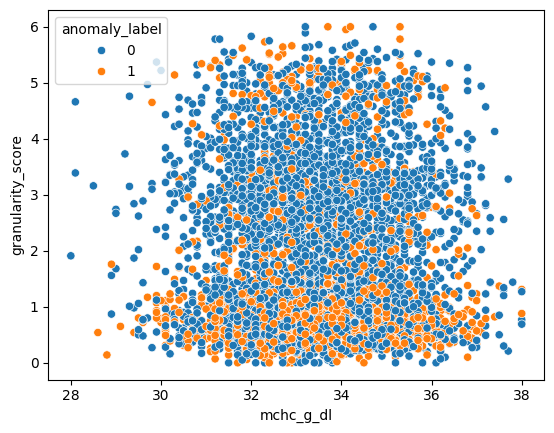

In [62]:
sns.scatterplot(x=df["mchc_g_dl"] , y=df["granularity_score"] , hue = df["anomaly_label"])
plt.show()

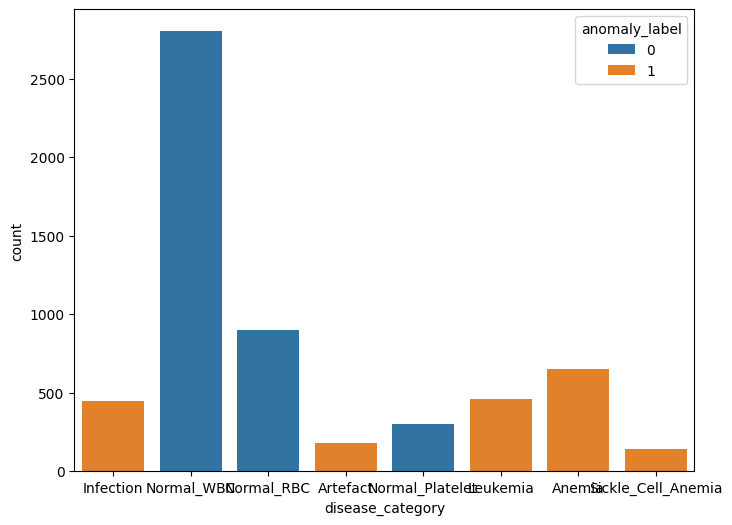

In [60]:
fig , ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x=df["disease_category"] , hue=df["anomaly_label"])
plt.show()

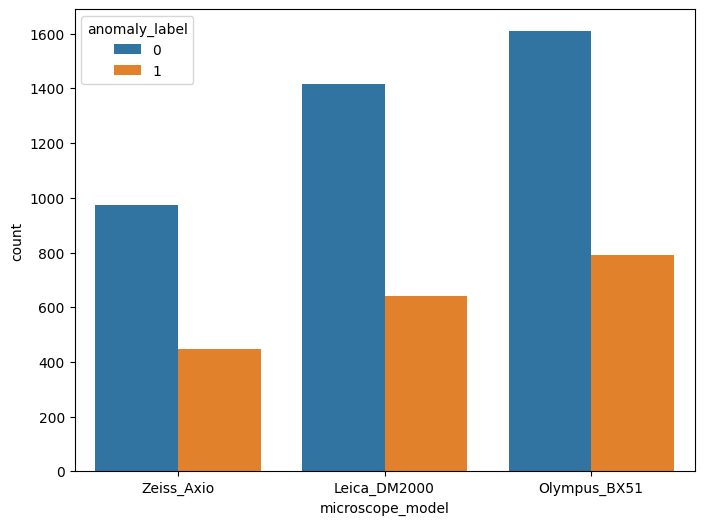

In [61]:
fig , ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x=df["microscope_model"] , hue = df["anomaly_label"])
plt.show()

In [8]:
df = df.drop("dataset_source",axis = 1)

In [9]:
from sklearn.preprocessing import OneHotEncoder , LabelEncoder

In [10]:
onehot = OneHotEncoder(sparse_output=False)

In [11]:
label = LabelEncoder()

In [12]:
df.head()

,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,...,platelet_count_per_ul,mcv_fl,mchc_g_dl,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,4.11,...,257383,85.5,31.4,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,2.50,...,302274,92.5,35.0,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,3.01,...,229996,76.3,33.0,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,...,130720,92.3,32.5,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,...,228652,83.9,33.4,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [37]:
X = df.drop(["anomaly_label","cytodiffusion_anomaly_score","cytodiffusion_classification_confidence","labeller_confidence_score","cell_type"] , axis = 1)
y = df["anomaly_label"]

In [38]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [39]:
df["staining_protocol"].value_counts()

staining_protocol
Giemsa                 2627
Wright                 2086
May_Grunwald_Giemsa    1167
Name: count, dtype: int64

In [40]:
df["microscope_model"].value_counts()

microscope_model
Olympus_BX51    2398
Leica_DM2000    2059
Zeiss_Axio      1423
Name: count, dtype: int64

In [41]:
df["cell_type"].value_counts()

cell_type
Neutrophil                   1100
Normal_RBC                    900
Lymphocyte                    850
Monocyte                      400
Platelet                      300
Eosinophil                    300
Blast_Cell                    280
Elliptocyte                   200
Prolymphocyte                 180
Schistocyte                   170
Hypersegmented_Neutrophil     160
Reactive_Lymphocyte           150
Basophil                      150
Spherocyte                    150
Toxic_Granulation             140
Sickle_Cell                   140
Target_Cell                   130
Smudge_Cell                   100
Artefact                       80
Name: count, dtype: int64

In [42]:
df.columns

Index(['cell_type', 'anomaly_label', 'disease_category', 'cell_diameter_um',
       'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio',
       'circularity', 'eccentricity', 'granularity_score', 'lobularity_score',
       'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r',
       'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group',
       'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul',
       'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl',
       'mchc_g_dl', 'staining_protocol', 'microscope_model', 'magnification_x',
       'image_resolution_px', 'cytodiffusion_anomaly_score',
       'cytodiffusion_classification_confidence', 'labeller_confidence_score'],
      dtype='str')

In [43]:
df.dtypes

cell_type                                      str
anomaly_label                                int64
disease_category                               str
cell_diameter_um                           float64
nucleus_area_pct                           float64
chromatin_density                          float64
cytoplasm_ratio                            float64
circularity                                float64
eccentricity                               float64
granularity_score                          float64
lobularity_score                           float64
membrane_smoothness                        float64
cell_area_px                                 int64
perimeter_px                                 int64
mean_r                                       int64
mean_g                                       int64
mean_b                                       int64
stain_intensity                            float64
patient_age_group                              str
patient_sex                    

In [44]:
categoric = [col for col in df.columns if df[col].dtype == "str" ]

In [45]:
categoric 

['cell_type',
 'disease_category',
 'patient_age_group',
 'patient_sex',
 'staining_protocol',
 'microscope_model']

In [50]:
onehot_categories = ['disease_category',
 'patient_age_group',
 'patient_sex',
 'staining_protocol',
 'microscope_model']

In [51]:
X_train_encoded = onehot.fit_transform(X_train[onehot_categories])
X_test_encoded = onehot.transform(X_test[onehot_categories])

In [52]:
X_train_final = pd.concat([X_train.drop(columns=onehot_categories) , pd.DataFrame(X_train_encoded,index=X_train.index).add_prefix("enc")] , axis = 1)
X_test_final = pd.concat([X_test.drop(columns=onehot_categories) , pd.DataFrame(X_test_encoded,index=X_test.index).add_prefix("enc")] , axis = 1)

In [53]:
X_train_final

,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,...,enc9,enc10,enc11,enc12,enc13,enc14,enc15,enc16,enc17,enc18
3276,11.51,59.0,0.487,0.324,0.801,0.322,3.25,3.7,0.827,334,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3116,8.13,81.6,0.846,0.165,0.946,0.311,1.14,1.0,0.843,258,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3887,12.40,54.4,0.611,0.371,0.740,0.430,5.45,2.5,0.781,469,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4903,13.27,54.8,0.766,0.519,0.764,0.328,5.08,1.9,0.725,440,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3534,11.66,54.1,0.545,0.473,0.780,0.369,3.85,3.8,0.772,457,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,11.48,84.5,0.882,0.153,0.844,0.309,0.94,1.0,0.844,271,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
5191,4.25,0.0,0.000,1.000,0.467,0.788,0.65,1.0,0.716,84,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
5226,8.34,0.0,0.000,1.000,0.894,0.095,0.51,1.0,1.000,215,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5390,7.37,0.0,0.000,1.000,0.825,0.181,0.36,1.0,0.931,198,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
model = RandomForestClassifier(max_depth = 5 , n_estimators = 5)

In [56]:
model.fit(X_train_final,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [57]:
y_pred = model.predict(X_test_final)

In [58]:
from sklearn.metrics import accuracy_score

In [59]:
accuracy_score(y_test,y_pred)

0.9753401360544217